In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os 


In [2]:
photo = cv2.imread("cat.jpg")
photo = cv2.cvtColor(photo,cv2.COLOR_BGR2RGB)

In [3]:
print(photo)

[[[177 175 127]
  [175 173 125]
  [182 180 132]
  ...
  [ 81 110  43]
  [ 76 105  38]
  [ 75 106  38]]

 [[186 182 137]
  [176 173 128]
  [184 181 136]
  ...
  [ 75 104  37]
  [ 78 109  41]
  [ 79 110  42]]

 [[184 180 135]
  [182 178 133]
  [184 180 135]
  ...
  [ 73 103  33]
  [ 73 104  34]
  [ 78 109  39]]

 ...

 [[159 174  81]
  [161 175  87]
  [165 179  92]
  ...
  [ 45  64  34]
  [ 44  66  30]
  [ 46  68  30]]

 [[168 182  87]
  [169 184  93]
  [164 178  91]
  ...
  [ 45  64  32]
  [ 42  64  28]
  [ 47  69  31]]

 [[166 180  85]
  [168 181  91]
  [160 174  86]
  ...
  [ 44  63  31]
  [ 48  70  34]
  [ 40  62  24]]]


In [4]:
pixel = photo.reshape((-1,3))
pixel = np.float32(pixel)

In [5]:
k = 4

In [6]:
when_stop = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,100,0.2)

In [7]:
Error,label,centers=cv2.kmeans(pixel,k,None,when_stop,10,cv2.KMEANS_RANDOM_CENTERS)

In [8]:
centers = np.uint8(centers)

In [10]:
compressed=centers[label.flatten()]

In [11]:
compressed=compressed.reshape(photo.shape)

In [12]:
cv2.imwrite("compressed.jpg", cv2.cvtColor(compressed,cv2.COLOR_RGB2BGR))

True

In [13]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

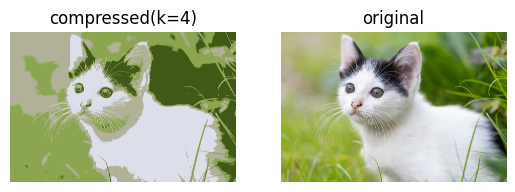

In [14]:
plt.subplot(1,2,2)
plt.title("original")
plt.imshow(photo)
plt.axis('off')

plt.subplot(1,2,1)
plt.title("compressed(k=4)")
plt.imshow(compressed)
plt.axis('off')
plt.show()